In [1]:
import h5py

fp = r"G:\data\MCD12C1 CMG\005Degree\GPM_3IMERGDF_07-20260319_034832\3B-DAY.MS.MRG.3IMERG.20020804-S000000-E235959.V07B.nc4"

with h5py.File(fp, "r") as f:
    print(list(f.keys()))

['precipitation', 'precipitation_cnt', 'precipitation_cnt_cond', 'MWprecipitation', 'MWprecipitation_cnt', 'MWprecipitation_cnt_cond', 'randomError', 'randomError_cnt', 'probabilityLiquidPrecipitation', 'lon', 'lat', 'time', 'nv', 'time_bnds']


In [2]:
import h5py

fp = r"G:\data\MCD12C1 CMG\005Degree\GPM_3IMERGDF_07-20260319_034832\3B-DAY.MS.MRG.3IMERG.20020804-S000000-E235959.V07B.nc4"

with h5py.File(fp, "r") as f:
    def show(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"[DATASET] {name} | shape={obj.shape} | dtype={obj.dtype}")
        else:
            print(f"[GROUP]   {name}")

    f.visititems(show)

[DATASET] MWprecipitation | shape=(1, 3600, 1800) | dtype=float32
[DATASET] MWprecipitation_cnt | shape=(1, 3600, 1800) | dtype=int8
[DATASET] MWprecipitation_cnt_cond | shape=(1, 3600, 1800) | dtype=int8
[DATASET] lat | shape=(1800,) | dtype=float64
[DATASET] lon | shape=(3600,) | dtype=float32
[DATASET] nv | shape=(2,) | dtype=>f4
[DATASET] precipitation | shape=(1, 3600, 1800) | dtype=float32
[DATASET] precipitation_cnt | shape=(1, 3600, 1800) | dtype=int8
[DATASET] precipitation_cnt_cond | shape=(1, 3600, 1800) | dtype=int8
[DATASET] probabilityLiquidPrecipitation | shape=(1, 3600, 1800) | dtype=int8
[DATASET] randomError | shape=(1, 3600, 1800) | dtype=float32
[DATASET] randomError_cnt | shape=(1, 3600, 1800) | dtype=int8
[DATASET] time | shape=(1,) | dtype=float64
[DATASET] time_bnds | shape=(1, 2) | dtype=float64


原始 shape: (3600, 1800)
转置后 shape: (1800, 3600)
lat range: -89.95 89.95 len = 1800
lon range: -179.95 179.95 len = 3600
min/max/mean: 0.0 757.6999 2.2815878


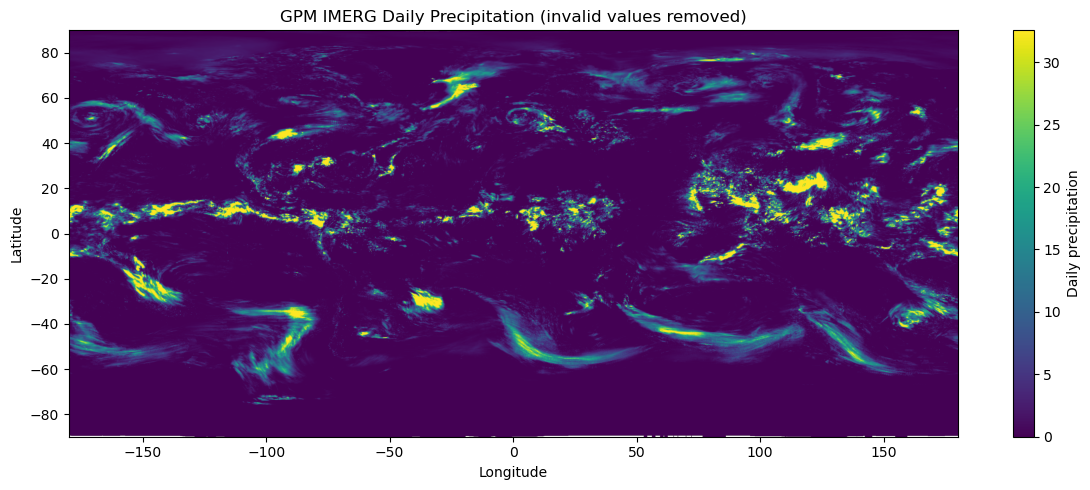

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

fp = r"G:\data\MCD12C1 CMG\005Degree\GPM_3IMERGDF_07-20260319_034832\3B-DAY.MS.MRG.3IMERG.20020804-S000000-E235959.V07B.nc4"

with h5py.File(fp, "r") as f:
    precip = f["precipitation"][0, :, :]   # 原始: (3600, 1800)
    lat = f["lat"][:]
    lon = f["lon"][:]

# 转置成 (1800, 3600)
precip_t = precip.T.astype(np.float32)

# 去除无效值：小于 0 的都视为无效
precip_t[precip_t < 0] = np.nan

print("原始 shape:", precip.shape)
print("转置后 shape:", precip_t.shape)
print("lat range:", lat.min(), lat.max(), "len =", len(lat))
print("lon range:", lon.min(), lon.max(), "len =", len(lon))
print("min/max/mean:", np.nanmin(precip_t), np.nanmax(precip_t), np.nanmean(precip_t))

# 为了让图更好看，可用分位数控制色标
vmin = 0
vmax = np.nanpercentile(precip_t, 99)   # 或者 95，看你想压多少极端值

plt.figure(figsize=(12, 5))
im = plt.imshow(
    precip_t,
    origin="lower",
    extent=[float(lon.min()), float(lon.max()), float(lat.min()), float(lat.max())],
    aspect="auto",
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(im, label="Daily precipitation")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("GPM IMERG Daily Precipitation (invalid values removed)")
plt.tight_layout()
plt.show()